# Enhanced DCA — Backtest

**Instrument:** S&P 500 (CRSP daily index, aggregated to monthly)
**Strategy:** Dollar-cost averaging with dynamic allocation based on prior month returns.
**Benchmarks:** Lump sum investing, basic (equal) DCA.

**Research question:** Does adjusting monthly contributions based on recent market
performance (invest more after down months, less after up months) improve long-term
returns vs standard DCA?

**Variants explored:**
1. **Ratio-based** — fixed multiplier: invest `up` after down months, `up/ratio` after up months
2. **Recursive** — investment compounds: each month is a factor of last month's investment
3. **Streak-based** — multiplier grows with consecutive up/down streaks, resets on reversal
4. **Threshold** — ratio-based + extra multiplier for big drops (>threshold)

**Conclusion:** Variants marginally outperform basic DCA but differences are small
and sensitive to parameter choice. Not compelling enough to pursue as an active strategy.
Archived as completed research.

Uses `shared/wrds_data.py` to load S&P 500 index data from parquet files.

## 1. Setup

In [9]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from shared.wrds_data import load_sp500_monthly

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [10]:
# =============================================================================
# CONFIGURATION
# =============================================================================

START_DATE       = "2000-01-01"
INITIAL_INVESTMENT = 100_000

## 3. Data Loading

In [11]:
# Load monthly S&P 500 data from WRDS parquet
# Columns: caldt (date), spindx (index level), sprtrn (monthly return)
monthly_sp500 = load_sp500_monthly(start_date=START_DATE)

print(f"Monthly periods: {len(monthly_sp500)}")
print(f"Date range: {monthly_sp500['caldt'].iloc[0].date()} → {monthly_sp500['caldt'].iloc[-1].date()}")
print(f"\nFirst 5 rows:")
print(monthly_sp500.head())

Loaded 08_na_index_daily_prices.parquet: 8,586,924 rows x 10 cols
Monthly periods: 316
Date range: 2000-01-31 → 2026-04-30

First 5 rows:
       caldt       spindx    sprtrn
0 2000-01-31  1919.840534 -0.041093
1 2000-02-29  1883.498946 -0.018929
2 2000-03-31  2067.759471  0.097829
3 2000-04-30  2005.549219 -0.030086
4 2000-05-31  1964.401345 -0.020517


## 4. Lump Sum Benchmark

In [12]:
# Lump sum: invest everything on day 1
monthly_sp500["cum_ret_lump"] = (1 + monthly_sp500["sprtrn"]).cumprod()
monthly_sp500["lump_value"] = INITIAL_INVESTMENT * monthly_sp500["cum_ret_lump"]

# Drawdown
monthly_sp500["running_max_lump"] = monthly_sp500["lump_value"].cummax()
monthly_sp500["drawdown_lump"] = (
    (monthly_sp500["lump_value"] - monthly_sp500["running_max_lump"])
    / monthly_sp500["running_max_lump"]
)

n_months = len(monthly_sp500)
final_lump = monthly_sp500["lump_value"].iloc[-1]
ann_return_lump = (final_lump / INITIAL_INVESTMENT) ** (12 / n_months) - 1
max_dd_lump = monthly_sp500["drawdown_lump"].min()

print(f"Lump Sum Results:")
print(f"  Final Value:      ${final_lump:,.2f}")
print(f"  Annualized Return: {ann_return_lump:.2%}")
print(f"  Max Drawdown:      {max_dd_lump:.2%}")

Lump Sum Results:
  Final Value:      $733,385.05
  Annualized Return: 7.86%
  Max Drawdown:      -50.95%


## 5. Basic DCA Benchmark

In [13]:
# Basic DCA: equal monthly investment
monthly_investment = INITIAL_INVESTMENT / n_months

monthly_sp500["dca_investment"] = monthly_investment
monthly_sp500["dca_units"] = monthly_sp500["dca_investment"] / monthly_sp500["spindx"]
monthly_sp500["cum_units_dca"] = monthly_sp500["dca_units"].cumsum()
monthly_sp500["dca_value"] = monthly_sp500["cum_units_dca"] * monthly_sp500["spindx"]
monthly_sp500["dca_total_invested"] = monthly_sp500["dca_investment"].cumsum()

# Drawdown
monthly_sp500["running_max_dca"] = monthly_sp500["dca_value"].cummax()
monthly_sp500["drawdown_dca"] = (
    (monthly_sp500["dca_value"] - monthly_sp500["running_max_dca"])
    / monthly_sp500["running_max_dca"]
)

final_dca = monthly_sp500["dca_value"].iloc[-1]
total_invested_dca = monthly_sp500["dca_total_invested"].iloc[-1]
ann_return_dca = (final_dca / total_invested_dca) ** (12 / n_months) - 1
max_dd_dca = monthly_sp500["drawdown_dca"].min()

print(f"Basic DCA Results:")
print(f"  Total Invested:    ${total_invested_dca:,.2f}")
print(f"  Final Value:       ${final_dca:,.2f}")
print(f"  Annualized Return: {ann_return_dca:.2%}")
print(f"  Max Drawdown:      {max_dd_dca:.2%}")

Basic DCA Results:
  Total Invested:    $100,000.00
  Final Value:       $535,990.30
  Annualized Return: 6.58%
  Max Drawdown:      -43.05%


## 6. Enhanced DCA Strategy Functions

All variants share the same structure: compute a per-month investment amount,
buy units, track portfolio value. The total invested is always normalized
to `INITIAL_INVESTMENT` for fair comparison.

In [14]:
def enhanced_dca_ratio(monthly_sp500, initial_investment, up_down_ratio):
    """
    Variant 1 — Ratio-based Enhanced DCA.
    
    After a down month: invest `up` (=1).
    After an up month: invest `up / up_down_ratio`.
    Higher ratio = more aggressive mean-reversion tilt.
    """
    df = monthly_sp500.copy()
    df["prev_return"] = df["sprtrn"].shift(1)

    up = 1
    down = up / up_down_ratio

    df["multiplier"] = df["prev_return"].apply(
        lambda ret: 0 if pd.isna(ret) else (up if ret < 0 else down)
    )

    total_multipliers = df["multiplier"].sum()
    df["enhanced_investment"] = initial_investment * (df["multiplier"] / total_multipliers)
    df["enhanced_units"] = df["enhanced_investment"] / df["spindx"]
    df["cum_units"] = df["enhanced_units"].cumsum()
    df["enhanced_value"] = df["cum_units"] * df["spindx"]

    total_invested = df["enhanced_investment"].sum()
    final_value = df["enhanced_value"].iloc[-1]
    cum_return = final_value / total_invested - 1
    ann_return = (1 + cum_return) ** (12 / len(df)) - 1

    running_max = df["enhanced_value"].cummax()
    drawdowns = (df["enhanced_value"] - running_max) / running_max
    max_dd = drawdowns.min()

    return ann_return, max_dd, total_invested, final_value, df


def enhanced_dca_recursive(monthly_sp500, initial_investment, up_factor, down_factor):
    """
    Variant 2 — Recursive Enhanced DCA.
    
    Each month's investment = previous month's investment * factor.
    After up month: multiply by up_factor (< 1 to reduce).
    After down month: multiply by down_factor (> 1 to increase).
    Normalized so total invested = initial_investment.
    """
    df = monthly_sp500.copy().reset_index(drop=True)
    df["prev_return"] = df["sprtrn"].shift(1)

    investments = np.zeros(len(df))
    investments[0] = initial_investment / len(df)

    for i in range(1, len(df)):
        if pd.isna(df.loc[i, "prev_return"]):
            investments[i] = initial_investment / len(df)
        elif df.loc[i, "prev_return"] < 0:
            investments[i] = investments[i - 1] * down_factor
        else:
            investments[i] = investments[i - 1] * up_factor

    # Normalize to total = initial_investment
    total = investments.sum()
    investments = investments * (initial_investment / total)

    df["enhanced_investment"] = investments
    df["enhanced_units"] = df["enhanced_investment"] / df["spindx"]
    df["cum_units"] = df["enhanced_units"].cumsum()
    df["enhanced_value"] = df["cum_units"] * df["spindx"]

    total_invested = investments.sum()
    final_value = df["enhanced_value"].iloc[-1]
    cum_return = final_value / total_invested - 1
    ann_return = (1 + cum_return) ** (12 / len(df)) - 1

    running_max = df["enhanced_value"].cummax()
    drawdowns = (df["enhanced_value"] - running_max) / running_max
    max_dd = drawdowns.min()

    return ann_return, max_dd, total_invested, final_value


def enhanced_dca_streak(monthly_sp500, initial_investment, up_factor, down_factor,
                        up_reset=1.0, down_reset=2.0):
    """
    Variant 3 — Streak-based Enhanced DCA.
    
    Multiplier grows with consecutive same-direction months.
    Resets to up_reset or down_reset when direction changes.
    """
    df = monthly_sp500.copy().reset_index(drop=True)
    df["prev_return"] = df["sprtrn"].shift(1)

    n_months = len(df)
    baseline = initial_investment / n_months
    investments = np.zeros(n_months)
    multiplier = 1.0

    for i in range(n_months):
        if pd.isna(df.loc[i, "prev_return"]):
            investments[i] = baseline
            continue

        curr_sign = np.sign(df.loc[i, "prev_return"])

        if i == 1:
            multiplier = up_reset if curr_sign >= 0 else down_reset
        else:
            prev_sign = np.sign(df.loc[i - 1, "prev_return"])
            if curr_sign == prev_sign:
                multiplier *= up_factor if curr_sign >= 0 else down_factor
            else:
                multiplier = up_reset if curr_sign >= 0 else down_reset

        investments[i] = baseline * multiplier

    total_invested = investments.sum()
    df["enhanced_investment"] = investments
    df["enhanced_units"] = df["enhanced_investment"] / df["spindx"]
    df["cum_units"] = df["enhanced_units"].cumsum()
    df["enhanced_value"] = df["cum_units"] * df["spindx"]

    final_value = df["enhanced_value"].iloc[-1]
    cum_return = final_value / total_invested - 1
    ann_return = (1 + cum_return) ** (12 / n_months) - 1

    return ann_return, total_invested, final_value


def enhanced_dca_threshold(monthly_sp500, initial_investment, up_down_ratio,
                           threshold, big_drop_multiplier=5):
    """
    Variant 4 — Threshold-based Enhanced DCA.
    
    Same as ratio-based, but if previous month dropped more than `threshold`,
    apply an additional big_drop_multiplier to invest even more aggressively.
    """
    df = monthly_sp500.copy()
    df["prev_return"] = df["sprtrn"].shift(1)

    up = 1
    down = up / up_down_ratio

    def get_multiplier(ret):
        if pd.isna(ret):
            return 0
        if ret < -threshold:
            return down * big_drop_multiplier
        return up if ret < 0 else down

    df["multiplier"] = df["prev_return"].apply(get_multiplier)
    total_multipliers = df["multiplier"].sum()
    df["enhanced_investment"] = initial_investment * (df["multiplier"] / total_multipliers)

    df["enhanced_units"] = df["enhanced_investment"] / df["spindx"]
    df["cum_units"] = df["enhanced_units"].cumsum()
    df["enhanced_value"] = df["cum_units"] * df["spindx"]

    total_invested = df["enhanced_investment"].sum()
    final_value = df["enhanced_value"].iloc[-1]
    cum_return = final_value / total_invested - 1
    ann_return = (1 + cum_return) ** (12 / len(df)) - 1

    running_max = df["enhanced_value"].cummax()
    drawdowns = (df["enhanced_value"] - running_max) / running_max
    max_dd = drawdowns.min()

    return ann_return, max_dd, total_invested, final_value

## 7. Variant 1 — Ratio-Based Grid Search

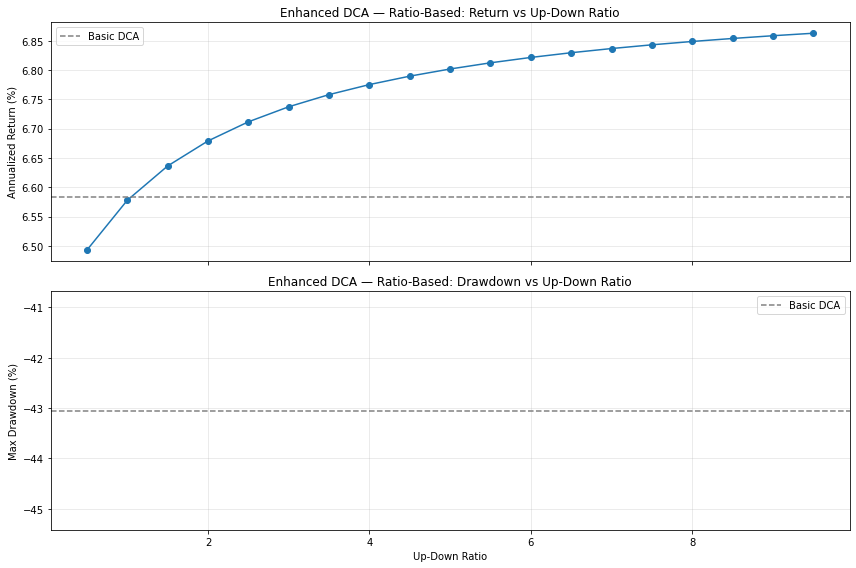

In [15]:
ratios = np.arange(0.5, 10, 0.5)
ratio_results = []

for r in ratios:
    ann, dd, inv, fv, _ = enhanced_dca_ratio(monthly_sp500, INITIAL_INVESTMENT, r)
    ratio_results.append({"ratio": r, "ann_return": ann, "max_dd": dd, "final_value": fv})

ratio_df = pd.DataFrame(ratio_results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(np.array(ratio_df["ratio"]), np.array(ratio_df["ann_return"] * 100), marker="o")
ax1.axhline(y=ann_return_dca * 100, color="gray", linestyle="--", label="Basic DCA")
ax1.set_ylabel("Annualized Return (%)")
ax1.set_title("Enhanced DCA — Ratio-Based: Return vs Up-Down Ratio")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(np.array(ratio_df["ratio"]), np.array(ratio_df["max_dd"] * 100), marker="x", color="red")
ax2.axhline(y=max_dd_dca * 100, color="gray", linestyle="--", label="Basic DCA")
ax2.set_xlabel("Up-Down Ratio")
ax2.set_ylabel("Max Drawdown (%)")
ax2.set_title("Enhanced DCA — Ratio-Based: Drawdown vs Up-Down Ratio")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Variant 2 — Recursive Grid Search

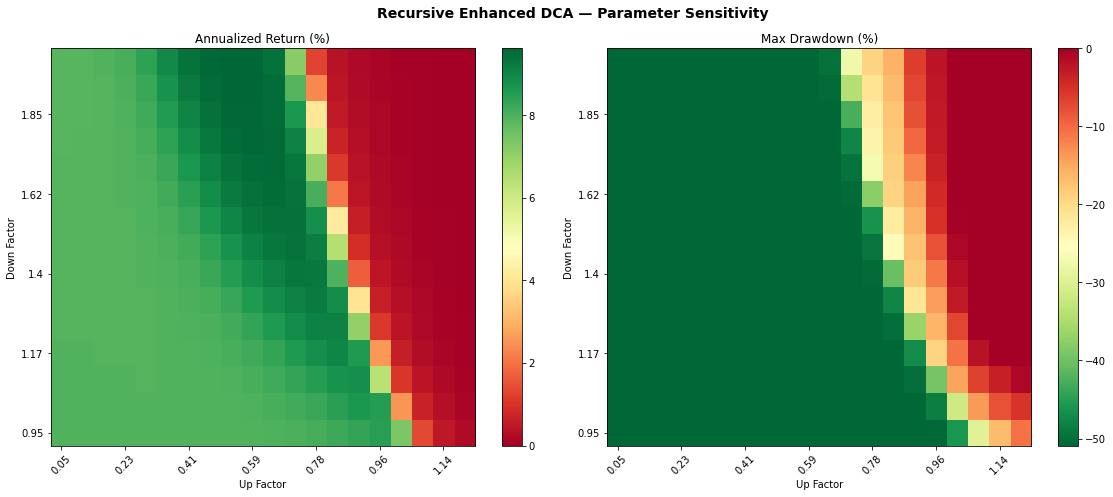

In [16]:
up_factors = np.linspace(0.05, 1.2, 20)
down_factors = np.linspace(0.95, 2, 15)

ann_returns_grid = np.zeros((len(down_factors), len(up_factors)))
dd_grid = np.zeros_like(ann_returns_grid)

for i, down in enumerate(down_factors):
    for j, up in enumerate(up_factors):
        ann, dd, _, _ = enhanced_dca_recursive(
            monthly_sp500, INITIAL_INVESTMENT, up, down)
        ann_returns_grid[i, j] = ann
        dd_grid[i, j] = dd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

im1 = ax1.imshow(ann_returns_grid * 100, aspect="auto", origin="lower", cmap="RdYlGn")
ax1.set_xticks(np.arange(0, len(up_factors), 3))
ax1.set_xticklabels(np.round(up_factors[::3], 2), rotation=45)
ax1.set_yticks(np.arange(0, len(down_factors), 3))
ax1.set_yticklabels(np.round(down_factors[::3], 2))
ax1.set_xlabel("Up Factor")
ax1.set_ylabel("Down Factor")
ax1.set_title("Annualized Return (%)")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(dd_grid * 100, aspect="auto", origin="lower", cmap="RdYlGn_r")
ax2.set_xticks(np.arange(0, len(up_factors), 3))
ax2.set_xticklabels(np.round(up_factors[::3], 2), rotation=45)
ax2.set_yticks(np.arange(0, len(down_factors), 3))
ax2.set_yticklabels(np.round(down_factors[::3], 2))
ax2.set_xlabel("Up Factor")
ax2.set_ylabel("Down Factor")
ax2.set_title("Max Drawdown (%)")
plt.colorbar(im2, ax=ax2)

plt.suptitle("Recursive Enhanced DCA — Parameter Sensitivity", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Variant 4 — Threshold Grid Search

In [17]:
up_down_ratios = [0.3, 0.5, 0.8, 1, 3]
thresholds = [0, 0.05, 0.1, 0.15, 0.2, 0.3]
big_drop_multipliers = [3]

thresh_results = []
for udr, thr, bdm in product(up_down_ratios, thresholds, big_drop_multipliers):
    ann, dd, inv, fv = enhanced_dca_threshold(
        monthly_sp500, INITIAL_INVESTMENT, udr, thr, bdm)
    thresh_results.append({
        "up_down_ratio": udr, "threshold": thr, "big_drop_mult": bdm,
        "ann_return": ann, "max_dd": dd, "final_value": fv,
    })

thresh_df = pd.DataFrame(thresh_results)
thresh_df = thresh_df.sort_values("final_value", ascending=False)
print("Top 10 Threshold Variants:")
print(thresh_df.head(10).to_string(index=False))

Top 10 Threshold Variants:
 up_down_ratio  threshold  big_drop_mult  ann_return  max_dd   final_value
           0.3       0.05              3    0.068067     NaN 566363.835797
           0.5       0.05              3    0.067988     NaN 565262.579905
           0.8       0.05              3    0.067882     NaN 563780.440757
           1.0       0.05              3    0.067818     NaN 562889.874031
           0.3       0.00              3    0.067374     NaN 556757.070019
           0.8       0.00              3    0.067374     NaN 556757.070019
           3.0       0.20              3    0.067374     NaN 556757.070019
           3.0       0.15              3    0.067374     NaN 556757.070019
           3.0       0.10              3    0.067374     NaN 556757.070019
           3.0       0.05              3    0.067374     NaN 556757.070019


## 10. Final Comparison

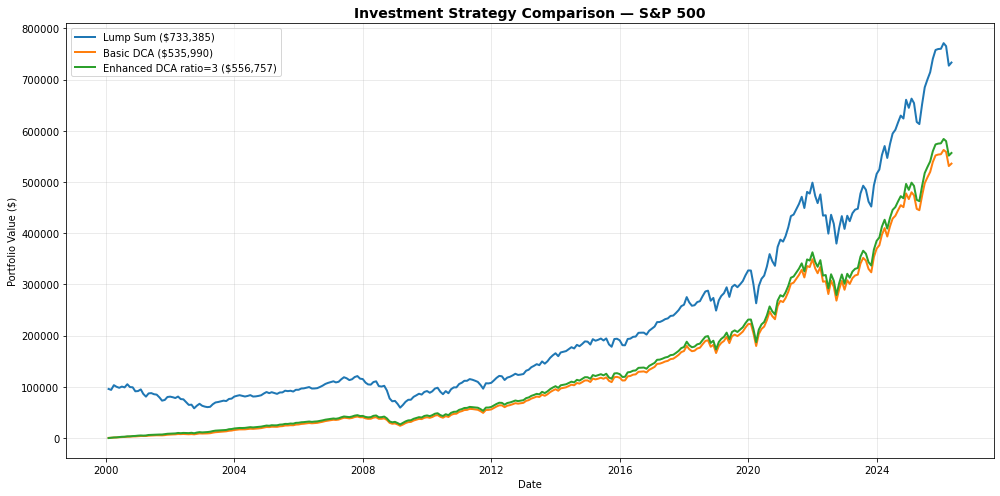


Summary:
  Strategy                      Final Value  Ann. Return     Max DD
  --------------------------------------------------------------
  Lump Sum                  $    733,385.05       7.86%   -50.95%
  Basic DCA                 $    535,990.30       6.58%   -43.05%
  Enhanced DCA (best)       $    574,241.10       6.86%      nan%


In [18]:
# Run best of each variant for comparison plot
_, _, _, _, ratio_best_df = enhanced_dca_ratio(monthly_sp500, INITIAL_INVESTMENT, up_down_ratio=3)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(np.array(monthly_sp500["caldt"]), np.array(monthly_sp500["lump_value"]),
        label=f"Lump Sum (${final_lump:,.0f})", linewidth=2)
ax.plot(np.array(monthly_sp500["caldt"]), np.array(monthly_sp500["dca_value"]),
        label=f"Basic DCA (${final_dca:,.0f})", linewidth=2)
ax.plot(np.array(monthly_sp500["caldt"]), np.array(ratio_best_df["enhanced_value"]),
        label=f"Enhanced DCA ratio=3 (${ratio_best_df['enhanced_value'].iloc[-1]:,.0f})",
        linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Investment Strategy Comparison — S&P 500", fontsize=14, fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\nSummary:")
print(f"  {'Strategy':<25} {'Final Value':>15} {'Ann. Return':>12} {'Max DD':>10}")
print(f"  {'-'*62}")
print(f"  {'Lump Sum':<25} ${final_lump:>14,.2f} {ann_return_lump:>11.2%} {max_dd_lump:>9.2%}")
print(f"  {'Basic DCA':<25} ${final_dca:>14,.2f} {ann_return_dca:>11.2%} {max_dd_dca:>9.2%}")

best_ratio = ratio_df.loc[ratio_df["ann_return"].idxmax()]
print(f"  {'Enhanced DCA (best)':<25} ${best_ratio['final_value']:>14,.2f} {best_ratio['ann_return']:>11.2%} {best_ratio['max_dd']:>9.2%}")

## 11. Conclusion

**Finding:** Enhanced DCA variants produce marginal improvements over basic DCA,
but the differences are small and parameter-dependent. Lump sum investing consistently
outperforms all DCA variants over this period — which is expected since markets trend
upward and earlier capital deployment captures more compounding.

**Why DCA still matters:** DCA is a behavioral tool, not a return-maximization tool.
It reduces timing risk and makes investing psychologically easier. The "enhanced"
variants add complexity without meaningful improvement.

**Status:** Archived. Not pursuing further. The research confirms the academic consensus:
lump sum beats DCA on average, and tweaking DCA allocation rules doesn't change this
conclusion materially.